In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("diabetes_binary_health_indicators_BRFSS2015.csv")

df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
df.shape

(253680, 22)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [5]:
df.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [6]:
df.isnull().sum()

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(24206)

In [8]:
df = df.drop_duplicates()

In [9]:
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

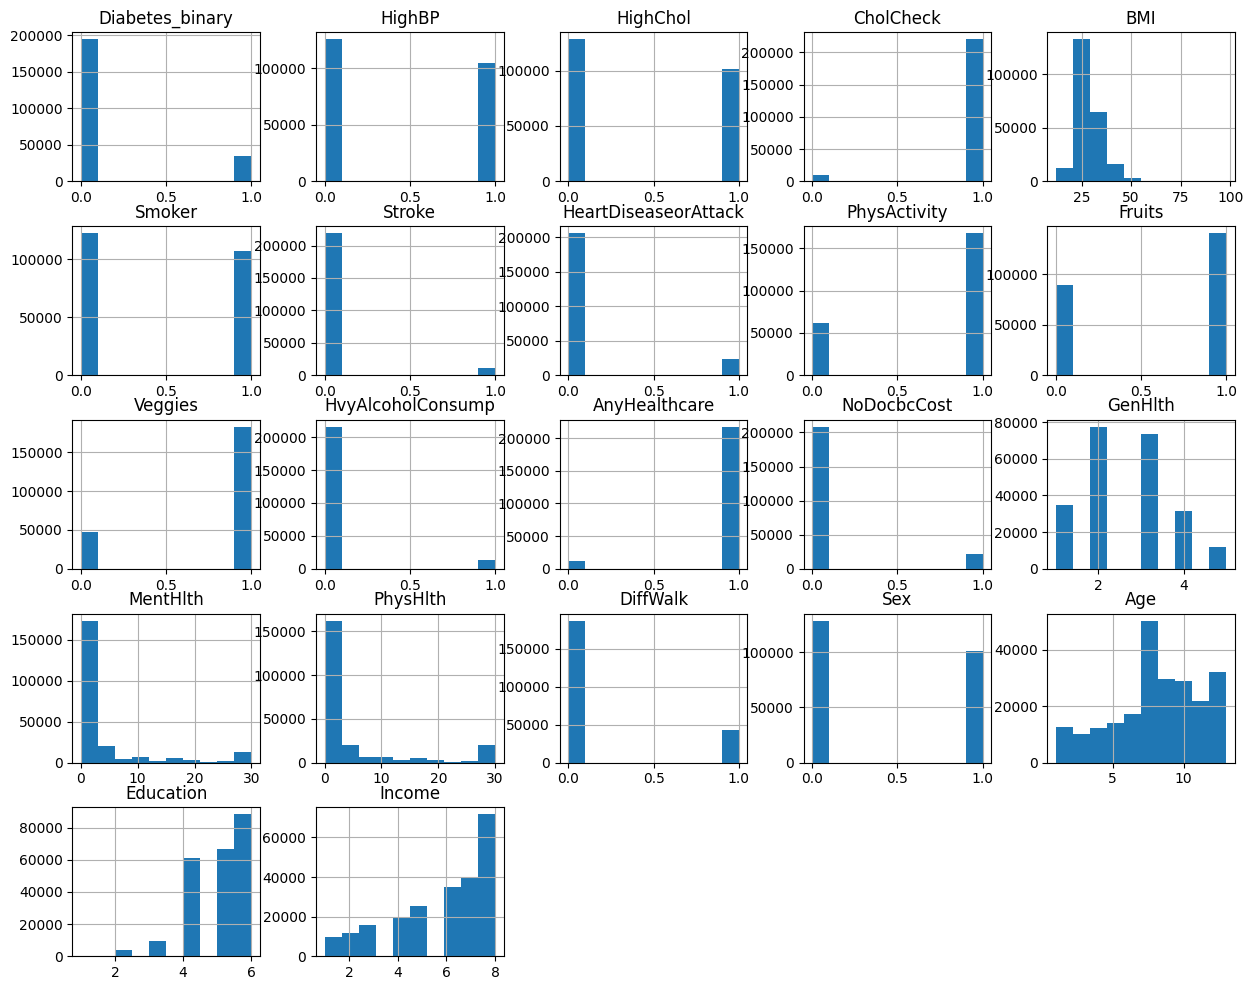

In [10]:
df.hist(figsize=(15,12))
plt.show()

In [11]:
cols = ['BMI', 'MentHlth', 'PhysHlth']

scaler = StandardScaler()
df[cols] = scaler.fit_transform(df[cols])

print(df)

        Diabetes_binary  HighBP  HighChol  CholCheck       BMI  Smoker  \
0                   0.0     1.0       1.0        1.0  1.666251     1.0   
1                   0.0     0.0       0.0        0.0 -0.543144     1.0   
2                   0.0     1.0       1.0        1.0 -0.101265     0.0   
3                   0.0     1.0       0.0        1.0 -0.248558     0.0   
4                   0.0     1.0       1.0        1.0 -0.690437     0.0   
...                 ...     ...       ...        ...       ...     ...   
253675              0.0     1.0       1.0        1.0  2.402716     0.0   
253676              1.0     1.0       1.0        1.0 -1.574195     0.0   
253677              0.0     0.0       0.0        1.0 -0.101265     0.0   
253678              0.0     1.0       0.0        1.0 -0.837730     0.0   
253679              1.0     1.0       1.0        1.0 -0.543144     0.0   

        Stroke  HeartDiseaseorAttack  PhysActivity  Fruits  ...  \
0          0.0                   0.0        

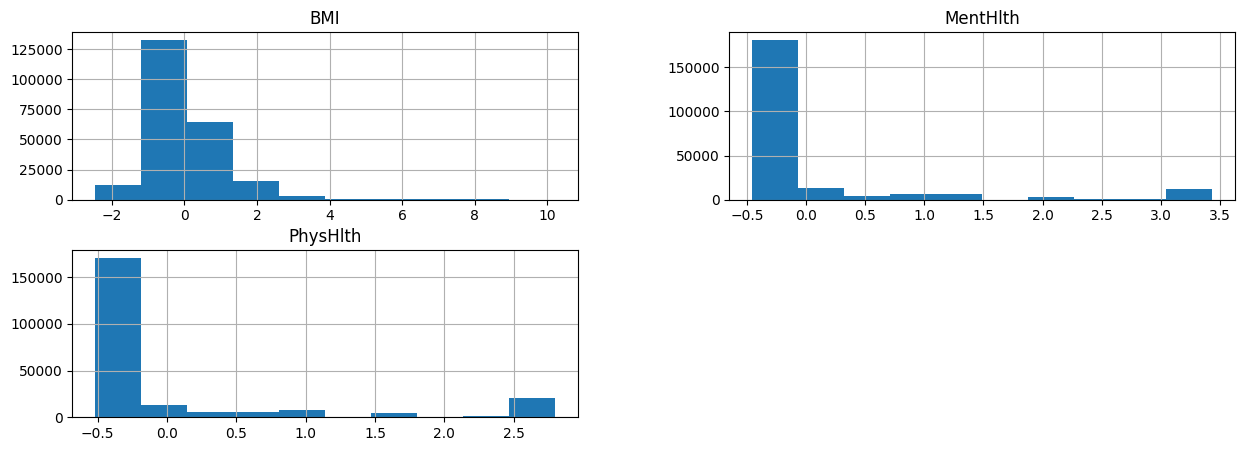

In [12]:
cols = ['BMI', 'MentHlth', 'PhysHlth']
df[cols].hist(figsize=(15, 5)) # figsize adapté pour 3 graphiques
plt.show()

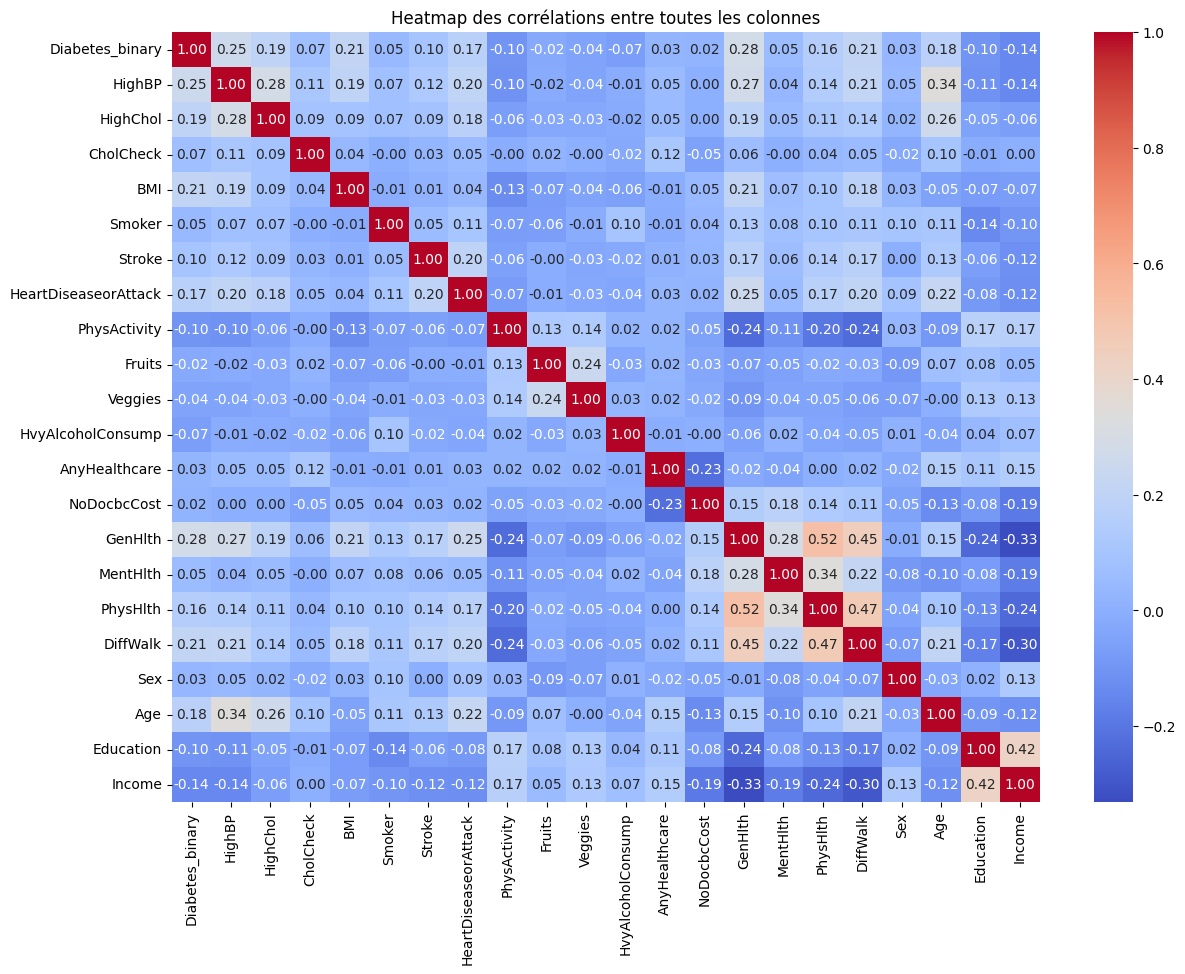

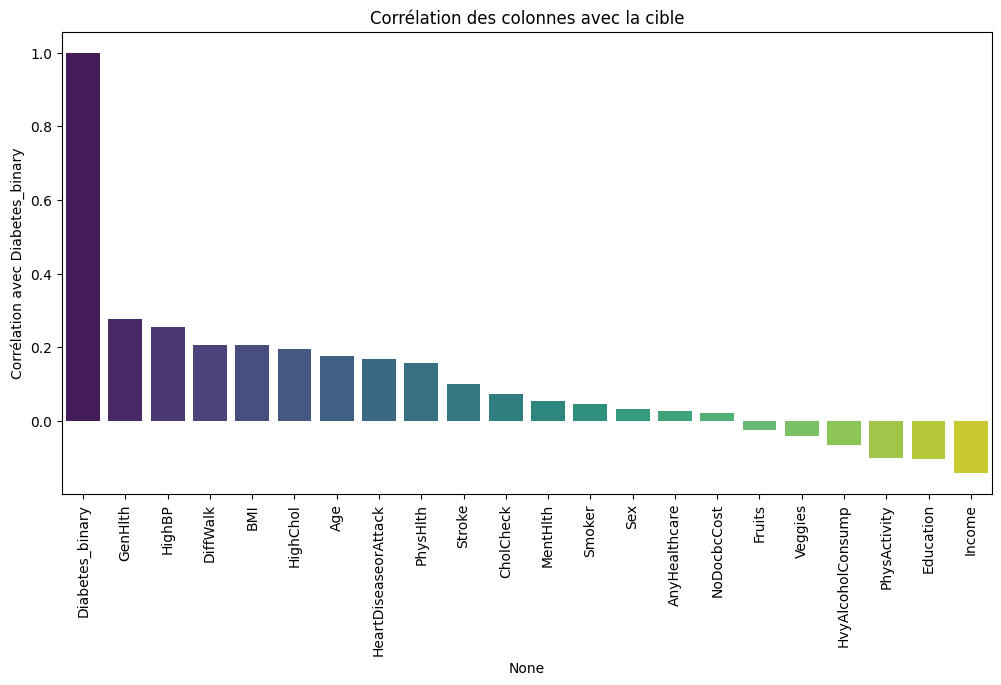

In [13]:
corr_matrix = df.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Heatmap des corrélations entre toutes les colonnes")
plt.show()

corr_with_target = corr_matrix['Diabetes_binary'].sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(
    x=corr_with_target.index, 
    y=corr_with_target.values, 
    hue=corr_with_target.index,  # <-- L'ajout demandé par Seaborn
    palette="viridis", 
    legend=False                 # <-- Masque la légende inutile
)
plt.xticks(rotation=90)
plt.ylabel("Corrélation avec Diabetes_binary")
plt.title("Corrélation des colonnes avec la cible")
plt.show()

In [14]:
corr_target = corr_matrix["Diabetes_binary"].sort_values(ascending=False)

corr_target

Diabetes_binary         1.000000
GenHlth                 0.276940
HighBP                  0.254318
DiffWalk                0.205302
BMI                     0.205086
HighChol                0.194944
Age                     0.177263
HeartDiseaseorAttack    0.168213
PhysHlth                0.156211
Stroke                  0.099193
CholCheck               0.072523
MentHlth                0.054153
Smoker                  0.045504
Sex                     0.032724
AnyHealthcare           0.025331
NoDocbcCost             0.020048
Fruits                 -0.024805
Veggies                -0.041734
HvyAlcoholConsump      -0.065950
PhysActivity           -0.100404
Education              -0.102686
Income                 -0.140659
Name: Diabetes_binary, dtype: float64

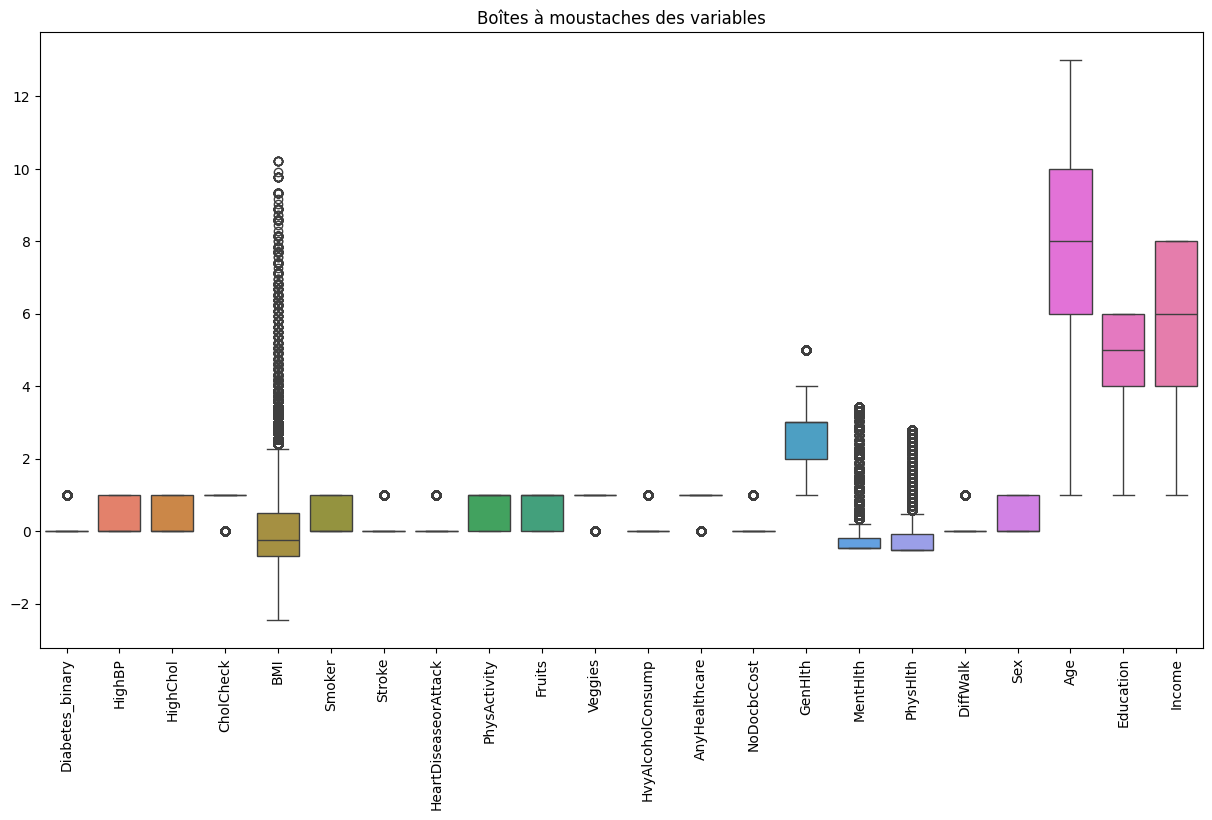

In [15]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.title("Boîtes à moustaches des variables")

plt.show()

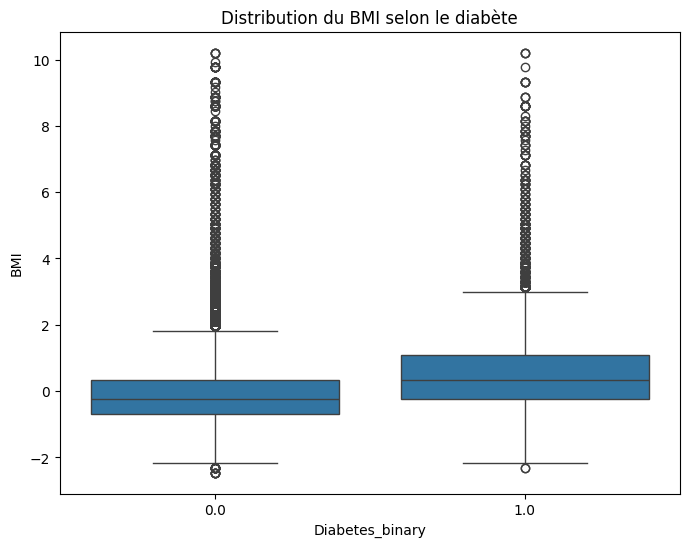

In [16]:
plt.figure(figsize=(8,6))

sns.boxplot(x="Diabetes_binary", y="BMI", data=df)

plt.title("Distribution du BMI selon le diabète")

plt.show()

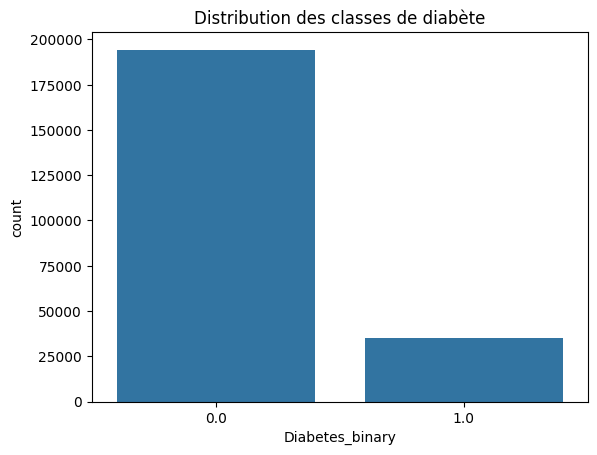

In [17]:
sns.countplot(x="Diabetes_binary", data=df)

plt.title("Distribution des classes de diabète")

plt.show()

In [18]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [19]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

In [21]:
df.to_csv("diabetes_clean.csv", index=False)

In [22]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

Traiter le déséquilibre uniquement sur l’ensemble d’entraînement

In [23]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

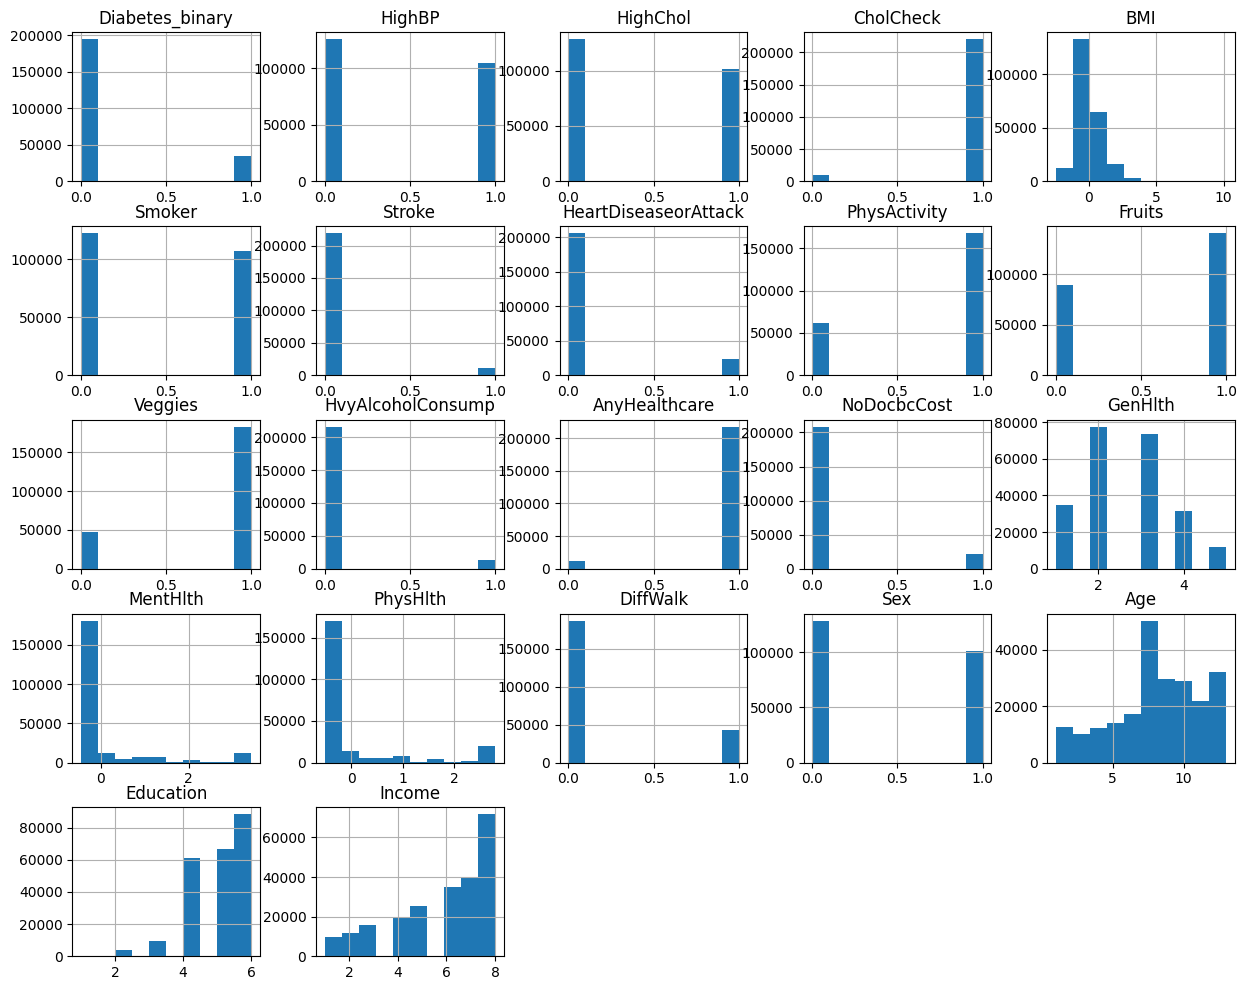

In [24]:
df.hist(figsize=(15,12))
plt.show()